<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
             padding: 40px 30px; border-radius: 16px; text-align: center; color: white;
             font-family: 'Segoe UI', sans-serif; box-shadow: 0 8px 32px rgba(0,0,0,0.2);">
  <h1 style="font-size: 2.8em; margin: 0 0 10px 0; letter-spacing: 2px;">💼 Salary Data Analysis</h1>
  <p style="font-size: 1.2em; opacity: 0.9; margin: 0 0 20px 0;">
    Uncovering compensation patterns across job roles, cities, and companies
  </p>
  <div style="display: flex; justify-content: center; gap: 20px; flex-wrap: wrap; font-size: 0.95em;">
    <span style="background: rgba(255,255,255,0.2); padding: 6px 16px; border-radius: 20px;">📁 Dataset: Salary_Dataset_DSL.csv</span>
    <span style="background: rgba(255,255,255,0.2); padding: 6px 16px; border-radius: 20px;">🐍 Python · Pandas · Seaborn</span>
    <span style="background: rgba(255,255,255,0.2); padding: 6px 16px; border-radius: 20px;">📊 7 Key Questions</span>
  </div>
</div>

---

### 🗺️ Project Roadmap

| Step | Section | Description |
|:----:|---------|-------------|
| 1 | 📦 Libraries | Import all required packages |
| 2 | 📂 Load Data | Read & preview the dataset |
| 3 | 🔍 EDA | Understand structure & statistics |
| 4 | 🧹 Data Cleaning | Handle nulls, duplicates & outliers |
| 5 | ❓ Analysis | Answer 7 business questions |
| 6 | 📈 Bonus Visuals | Job role distribution & rating trend |
| 7 | 📝 Insights | Summary & key takeaways |


---
<div style="background: linear-gradient(90deg, #f093fb, #f5576c);
            padding: 12px 24px; border-radius: 10px; display: inline-block; color: white;
            font-family: 'Segoe UI', sans-serif; font-size: 1.3em; font-weight: bold;">
  📦 Step 1 &nbsp;|&nbsp; Import Libraries
</div>

> All the tools we need: **NumPy** for numerics, **Pandas** for data wrangling,
> **Matplotlib & Seaborn** for visualisation, and **Warnings** to keep the output clean.


In [ ]:
# ─────────────────────────────────────────────────────────────
#  CORE LIBRARIES
# ─────────────────────────────────────────────────────────────
import numpy as np          # Numerical operations
import pandas as pd         # Data manipulation & analysis
import matplotlib.pyplot as plt  # Base plotting library
import seaborn as sns       # High-level statistical visualisations
import warnings
warnings.filterwarnings('ignore')  # Suppress deprecation noise

# ── Global Plot Aesthetics ────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')   # Clean grid background
sns.set_context('notebook', font_scale=1.1)  # Slightly larger fonts
sns.set_palette('husl')                   # Vibrant colour palette
TITLE_FONT  = {'fontsize': 15, 'fontweight': 'bold', 'color': '#2d2d2d'}
LABEL_FONT  = {'fontsize': 11, 'color': '#555555'}

print("All libraries imported successfully!")


All libraries imported successfully!


---
<div style="background: linear-gradient(90deg, #4facfe, #00f2fe);
            padding: 12px 24px; border-radius: 10px; display: inline-block; color: white;
            font-family: 'Segoe UI', sans-serif; font-size: 1.3em; font-weight: bold;">
  📂 Step 2 &nbsp;|&nbsp; Load Dataset
</div>



In [ ]:
# ─────────────────────────────────────────────────────────────
#  LOAD CSV INTO A DATAFRAME
# ─────────────────────────────────────────────────────────────
df = pd.read_csv('/content/Salary_Dataset_DSL.csv')

# Quick confirmation
print(f"Dataset loaded!  Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")
print(f"   Columns: {list(df.columns)}")
print()
df.head(10)   # Preview first 10 rows


Dataset loaded!  Rows: 22,770  |  Columns: 8
   Columns: ['Rating', 'Company Name', 'Job Title', 'Salary', 'Salaries Reported', 'Location', 'Employment Status', 'Job Roles']



,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android
2,4.0,Unacademy,Android Developer,1000000,3,Bangalore,Full Time,Android
3,3.8,SnapBizz Cloudtech,Android Developer,300000,3,Bangalore,Full Time,Android
4,4.4,Appoids Tech Solutions,Android Developer,600000,3,Bangalore,Full Time,Android
5,4.2,Freelancer,Android Developer,100000,3,Bangalore,Full Time,Android
6,3.7,SQUARE N CUBE,Android Developer,192000,3,Bangalore,Full Time,Android
7,3.1,Samsung R&D Institute India - Bangalore,Android Developer,400000,3,Bangalore,Full Time,Android
8,3.7,DXMinds Technologies,Android Developer,300000,3,Bangalore,Full Time,Android
9,3.6,Endeavour Software Technologies,Android Developer,600000,3,Bangalore,Full Time,Android


---
<div style="background: linear-gradient(90deg, #43e97b, #38f9d7);
            padding: 12px 24px; border-radius: 10px; display: inline-block; color: white;
            font-family: 'Segoe UI', sans-serif; font-size: 1.3em; font-weight: bold;">
  🔍 Step 3 &nbsp;|&nbsp; Exploratory Data Analysis (EDA)
</div>

> Before cleaning or visualising, we need to **understand what the data looks like** —
> its shape, data types, and basic statistics.


In [ ]:
# ─────────────────────────────────────────────────────────────
#  3a. DATASET DIMENSIONS
# ─────────────────────────────────────────────────────────────
rows, cols = df.shape
print(f"Shape: {rows:,} rows  ×  {cols} columns")


Shape: 22,770 rows  ×  8 columns


In [ ]:
# ─────────────────────────────────────────────────────────────
#  3b. COLUMN INFO
# ─────────────────────────────────────────────────────────────
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22770 entries, 0 to 22769
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Rating             22770 non-null  float64
 1   Company Name       22769 non-null  object 
 2   Job Title          22770 non-null  object 
 3   Salary             22770 non-null  int64  
 4   Salaries Reported  22770 non-null  int64  
 5   Location           22770 non-null  object 
 6   Employment Status  22770 non-null  object 
 7   Job Roles          22770 non-null  object 
dtypes: float64(1), int64(2), object(5)
memory usage: 1.4+ MB


In [ ]:
# ─────────────────────────────────────────────────────────────
#  3c. NUMERIC SUMMARY STATISTICS
# ─────────────────────────────────────────────────────────────
df.describe().style.format('{:.2f}')


,Rating,Salary,Salaries Reported
count,22770.00,22770.00,22770.00
mean,3.92,695387.21,1.86
std,0.52,884399.01,6.82
min,1.00,2112.00,1.00
25%,3.70,300000.00,1.00
50%,3.90,500000.00,1.00
75%,4.20,900000.00,1.00
max,5.00,90000000.00,361.00


In [ ]:
# ─────────────────────────────────────────────────────────────
#  3d. FULL SUMMARY  (includes categorical columns)
#  Useful for seeing unique counts & most-frequent values
# ─────────────────────────────────────────────────────────────
df.describe(include='all')


,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
count,22770.000000,22769,22770,2.277000e+04,22770.000000,22770,22770,22770
unique,NaN,11260,1080,NaN,NaN,10,4,11
top,NaN,Tata Consultancy Services,Software Development Engineer,NaN,NaN,Bangalore,Full Time,SDE
freq,NaN,271,2351,NaN,NaN,8264,20083,8183
mean,3.918213,NaN,NaN,6.953872e+05,1.855775,NaN,NaN,NaN
std,0.519675,NaN,NaN,8.843990e+05,6.823668,NaN,NaN,NaN
min,1.000000,NaN,NaN,2.112000e+03,1.000000,NaN,NaN,NaN
25%,3.700000,NaN,NaN,3.000000e+05,1.000000,NaN,NaN,NaN
50%,3.900000,NaN,NaN,5.000000e+05,1.000000,NaN,NaN,NaN
75%,4.200000,NaN,NaN,9.000000e+05,1.000000,NaN,NaN,NaN


---
<div style="background: linear-gradient(90deg, #fa709a, #fee140);
            padding: 12px 24px; border-radius: 10px; display: inline-block; color: white;
            font-family: 'Segoe UI', sans-serif; font-size: 1.3em; font-weight: bold;">
  🧹 Step 4 &nbsp;|&nbsp; Data Cleaning
</div>

> Good analysis requires clean data. We'll fix **missing values**, remove **duplicate rows**,
> and eliminate **salary outliers** that could skew our results.


### 🔎 4.1 — Check for Missing Values


In [ ]:
# ─────────────────────────────────────────────────────────────
#  Count NaN values in every column & show as a summary table
# ─────────────────────────────────────────────────────────────
missing       = df.isnull().sum()
missing_pct   = (missing / len(df) * 100).round(2)
missing_table = pd.DataFrame({
    'Missing Count': missing,
    'Missing %':     missing_pct
}).sort_values('Missing Count', ascending=False)

# Only show columns that actually have missing values
has_missing = missing_table[missing_table['Missing Count'] > 0]
if has_missing.empty:
    print("✅ No missing values found!")
else:
    print(has_missing)
print(f"\nTotal missing cells: {missing.sum()}")


              Missing Count  Missing %
Company Name              1        0.0

Total missing cells: 1


### 🛠️ 4.2 — Handle Missing Values


In [ ]:
# ─────────────────────────────────────────────────────────────
#  STRATEGY:
#  • Drop rows where 'Salary' or 'Job Title' is missing
#    → These are critical columns; rows without them are useless
#  • Fill remaining categorical NaN with 'Unknown'
#    → Keeps rows alive without distorting numeric stats
# ─────────────────────────────────────────────────────────────
critical_cols = ['Salary', 'Job Title']
df.dropna(subset=critical_cols, inplace=True)

# Fill missing text columns with 'Unknown'
cat_cols = df.select_dtypes(include='object').columns
df[cat_cols] = df[cat_cols].fillna('Unknown')

print(f"Missing values handled.")
print(f"Rows remaining : {len(df):,}")
print(f"Remaining nulls: {df.isnull().sum().sum()}")


Missing values handled.
Rows remaining : 22,770
Remaining nulls: 0


### 🗑️ 4.3 — Remove Duplicate Rows


In [ ]:
# ─────────────────────────────────────────────────────────────
#  Duplicate rows can inflate counts and bias averages.
#  pandas drop_duplicates() removes rows where ALL columns match.
# ─────────────────────────────────────────────────────────────
rows_before = len(df)
df          = df.drop_duplicates()
removed     = rows_before - len(df)

print(f"Duplicate rows removed : {removed:,}")
print(f"Clean rows remaining   : {len(df):,}")


Duplicate rows removed : 0
Clean rows remaining   : 22,770


### 📦 4.4 — Outlier Detection (Salary)
> We use the **IQR (Inter-Quartile Range) method** — a robust, distribution-free approach.  
> Values below `Q1 − 1.5×IQR` or above `Q3 + 1.5×IQR` are flagged as outliers.


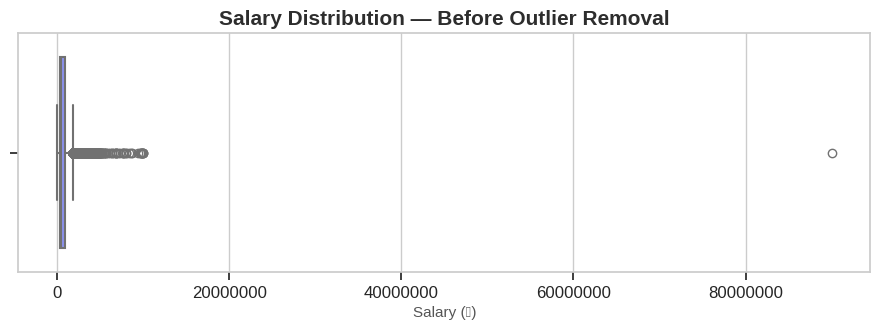

Skewness before removal: 46.7980


In [ ]:
# ─────────────────────────────────────────────────────────────
#  BEFORE — Boxplot to visualise outliers
# ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 3.5))
sns.boxplot(x=df['Salary'], color='#7c83fd', linewidth=1.5, ax=ax)
ax.set_title('Salary Distribution — Before Outlier Removal', **TITLE_FONT)
ax.set_xlabel('Salary (₹)', **LABEL_FONT)
ax.ticklabel_format(style='plain', axis='x')
plt.tight_layout()
plt.show()

print(f"Skewness before removal: {df['Salary'].skew():.4f}")


In [ ]:
# ─────────────────────────────────────────────────────────────
#  COMPUTE IQR BOUNDS
# ─────────────────────────────────────────────────────────────
Q1          = df['Salary'].quantile(0.25)   # 25th percentile
Q3          = df['Salary'].quantile(0.75)   # 75th percentile
IQR         = Q3 - Q1                       # Inter-quartile range
lower_limit = Q1 - 1.5 * IQR               # Anything below → outlier
upper_limit = Q3 + 1.5 * IQR               # Anything above → outlier

print(f"  Q1 (25th pct)  : ₹{Q1:>12,.0f}")
print(f"  Q3 (75th pct)  : ₹{Q3:>12,.0f}")
print(f"  IQR            : ₹{IQR:>12,.0f}")
print(f"  Lower limit    : ₹{lower_limit:>12,.0f}")
print(f"  Upper limit    : ₹{upper_limit:>12,.0f}")

# ── Trim the outliers ────────────────────────────────────────
rows_before = len(df)
df          = df[(df['Salary'] >= lower_limit) & (df['Salary'] <= upper_limit)]

print(f"\nOutliers removed : {rows_before - len(df):,}")
print(f"Rows remaining   : {len(df):,}")


  Q1 (25th pct)  : ₹     300,000
  Q3 (75th pct)  : ₹     800,000
  IQR            : ₹     500,000
  Lower limit    : ₹    -450,000
  Upper limit    : ₹   1,550,000

Outliers removed : 600
Rows remaining   : 21,014


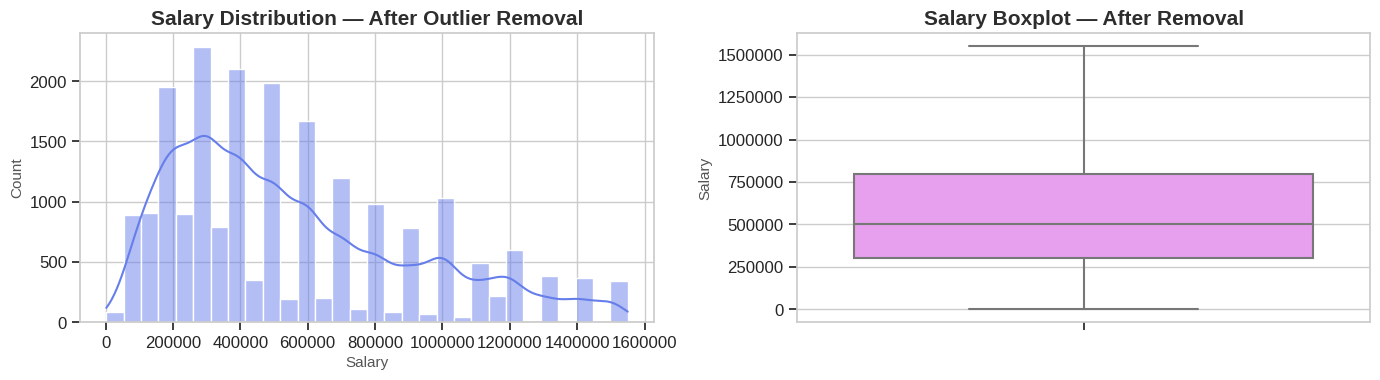

Skewness after removal: 0.8266


In [ ]:
# ─────────────────────────────────────────────────────────────
#  AFTER — Histogram + KDE to confirm cleaner distribution
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: histogram with KDE overlay
sns.histplot(df['Salary'], bins=30, kde=True, color='#667eea',
             edgecolor='white', ax=axes[0])
axes[0].set_title('Salary Distribution — After Outlier Removal', **TITLE_FONT)
axes[0].set_xlabel('Salary', **LABEL_FONT)
axes[0].set_ylabel('Count',  **LABEL_FONT)
axes[0].ticklabel_format(style='plain', axis='x')

# Right: clean boxplot after removal
sns.boxplot(y=df['Salary'], color='#f093fb', linewidth=1.5, ax=axes[1])
axes[1].set_title('Salary Boxplot — After Removal', **TITLE_FONT)
axes[1].set_ylabel('Salary', **LABEL_FONT)
axes[1].ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.show()

print(f"Skewness after removal: {df['Salary'].skew():.4f}")


---
<div style="background: linear-gradient(90deg, #a18cd1, #fbc2eb);
            padding: 12px 24px; border-radius: 10px; display: inline-block; color: white;
            font-family: 'Segoe UI', sans-serif; font-size: 1.3em; font-weight: bold;">
  ❓ Step 5 &nbsp;|&nbsp; Business Questions & Visualisations
</div>

> We now answer **7 key questions** about salary patterns using grouped aggregations
> and targeted visualisations.


---
<div style="background: #fff8e1; border-left: 6px solid #ffca28;
            padding: 14px 20px; border-radius: 8px; font-family: 'Segoe UI', sans-serif;">
  <b style="font-size: 1.15em; color: #e65100;">❓ Q1 — Which job role has the highest average salary?</b><br>
  <span style="color: #555;">Group by <code>Job Roles</code>, compute the mean salary, and rank descending.</span>
</div>


In [ ]:
# ─────────────────────────────────────────────────────────────
#  Explore the Job Roles column before aggregating
# ─────────────────────────────────────────────────────────────
print(f"Unique Job Roles: {df['Job Roles'].nunique()}")
print(f"Values: {df['Job Roles'].unique()}")


Unique Job Roles: 11
Values: ['Android' 'Backend' 'Database' 'Frontend' 'IOS' 'Java' 'Mobile' 'SDE'
 'Python' 'Web' 'Testing']


In [ ]:
# ─────────────────────────────────────────────────────────────
#  Compute average salary per job role → top 5
# ─────────────────────────────────────────────────────────────
job_salary = (df.groupby('Job Roles')['Salary']
               .mean()
               .sort_values(ascending=False)
               .head(5)
               .reset_index())
job_salary.columns = ['Job Role', 'Avg Salary']

# Pretty-print the table
print("\nTop 5 Job Roles by Average Salary")
print("─" * 42)
for _, row in job_salary.iterrows():
    print(f"  {row['Job Role']:<25}  ₹{row['Avg Salary']:>12,.0f}")



Top 5 Job Roles by Average Salary
──────────────────────────────────────────
  Database                   ₹     702,555
  SDE                        ₹     648,183
  IOS                        ₹     593,214
  Mobile                     ₹     589,858
  Backend                    ₹     529,105


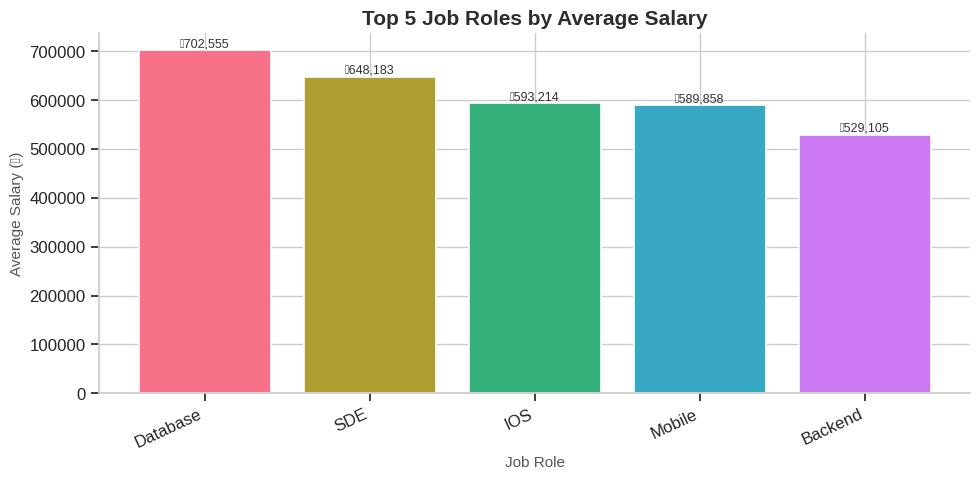

In [ ]:
# ─────────────────────────────────────────────────────────────
#  BAR CHART — Top 5 Job Roles vs Average Salary
# ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

colors = sns.color_palette('husl', 5)
bars   = ax.bar(job_salary['Job Role'], job_salary['Avg Salary'], color=colors,
                edgecolor='white', linewidth=1.2)

# Add value labels on top of each bar
for bar, val in zip(bars, job_salary['Avg Salary']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 500,
            f'₹{val:,.0f}', ha='center', va='bottom', fontsize=9, color='#333')

ax.set_title('Top 5 Job Roles by Average Salary', **TITLE_FONT)
ax.set_xlabel('Job Role', **LABEL_FONT)
ax.set_ylabel('Average Salary (₹)', **LABEL_FONT)
ax.ticklabel_format(style='plain', axis='y')
plt.xticks(rotation=25, ha='right')
sns.despine()
plt.tight_layout()
plt.show()


---
<div style="background: #e8f5e9; border-left: 6px solid #43a047;
            padding: 14px 20px; border-radius: 8px; font-family: 'Segoe UI', sans-serif;">
  <b style="font-size: 1.15em; color: #1b5e20;">❓ Q2 — Which city offers the highest average salary?</b><br>
  <span style="color: #555;">Group by <code>Location</code> and rank by mean salary.</span>
</div>


In [ ]:
# ─────────────────────────────────────────────────────────────
#  Average salary per city → top 5
# ─────────────────────────────────────────────────────────────
city_salary = (df.groupby('Location')['Salary']
                .mean()
                .sort_values(ascending=False)
                .head(5)
                .reset_index())
city_salary.columns = ['City', 'Avg Salary']

print("\nTop 5 Cities by Average Salary")
print("─" * 40)
for _, row in city_salary.iterrows():
    print(f"  {row['City']:<22}  ₹{row['Avg Salary']:>12,.0f}")



Top 5 Cities by Average Salary
────────────────────────────────────────
  Mumbai                  ₹     702,196
  Bangalore               ₹     568,223
  Jaipur                  ₹     566,154
  Pune                    ₹     562,387
  New Delhi               ₹     542,717


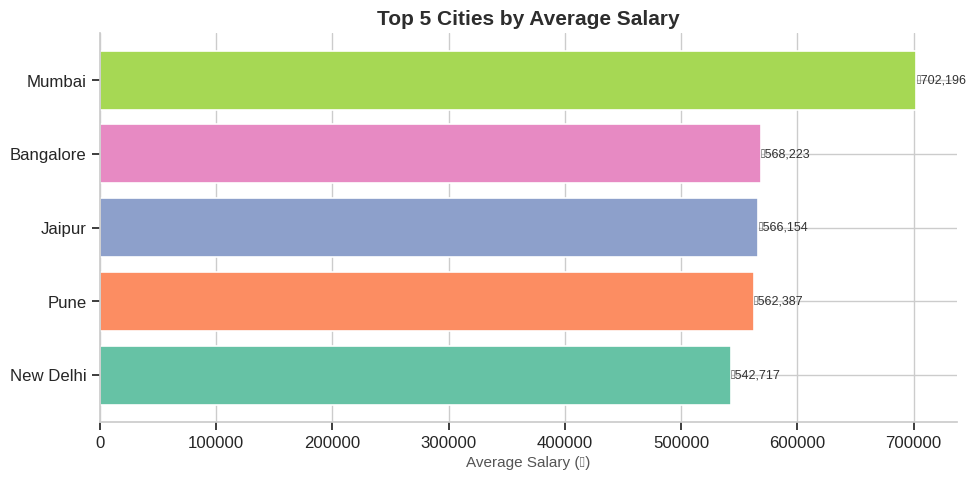

In [ ]:
# ─────────────────────────────────────────────────────────────
#  HORIZONTAL BAR CHART — easier to read city names
# ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

colors = sns.color_palette('Set2', 5)
hbars  = ax.barh(city_salary['City'][::-1],
                 city_salary['Avg Salary'][::-1],
                 color=colors, edgecolor='white', linewidth=1.2)

# Value labels at end of each bar
for bar, val in zip(hbars, city_salary['Avg Salary'][::-1]):
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height() / 2,
            f'₹{val:,.0f}', va='center', fontsize=9, color='#333')

ax.set_title('Top 5 Cities by Average Salary', **TITLE_FONT)
ax.set_xlabel('Average Salary (₹)', **LABEL_FONT)
ax.ticklabel_format(style='plain', axis='x')
sns.despine()
plt.tight_layout()
plt.show()


---
<div style="background: #fce4ec; border-left: 6px solid #e91e63;
            padding: 14px 20px; border-radius: 8px; font-family: 'Segoe UI', sans-serif;">
  <b style="font-size: 1.15em; color: #880e4f;">❓ Q3 — Companies in New Delhi with Rating = 5 (Top 5 vs Bottom 5 by Salary)</b><br>
  <span style="color: #555;">Filter the dataset, sort by salary, then display highest & lowest earners.</span>
</div>


In [ ]:
# ─────────────────────────────────────────────────────────────
#  Filter: Location == 'New Delhi'  AND  Rating == 5
#  Sort descending by Salary to get top/bottom split easily
# ─────────────────────────────────────────────────────────────
df1 = (df[(df['Location'] == 'New Delhi') & (df['Rating'] == 5)]
        .sort_values(by='Salary', ascending=False)
        .reset_index(drop=True))

print(f"Total New Delhi companies with 5-star rating: {len(df1)}")

print("\n Top 5 — Highest Paying")
print("─" * 45)
print(df1[['Company Name', 'Job Title', 'Salary']].head(5).to_string(index=False))

print("\n Bottom 5 — Lowest Paying")
print("─" * 45)
print(df1[['Company Name', 'Job Title', 'Salary']].tail(5).to_string(index=False))


Total New Delhi companies with 5-star rating: 137

 Top 5 — Highest Paying
─────────────────────────────────────────────
            Company Name                     Job Title  Salary
                Trillbit             Android Developer 1500000
                 Hapramp           Front End Developer 1500000
 The Art of Mike Mignola Software Development Engineer 1500000
Silicon Valley Recycling          Senior IOS Developer 1400000
         Parth Universal Software Development Engineer 1300000

 Bottom 5 — Lowest Paying
─────────────────────────────────────────────
  Company Name                                    Job Title  Salary
       Rabbler                     IOS Developer Contractor  100000
 WorkingNation                   Android Developer - Intern   84000
 Hopin (India)                   Android Developer - Intern   60000
Star Catalysts       Software Development Engineer - Intern   60000
        Atom 8 Software Development Engineer (SDE) - Intern   60000


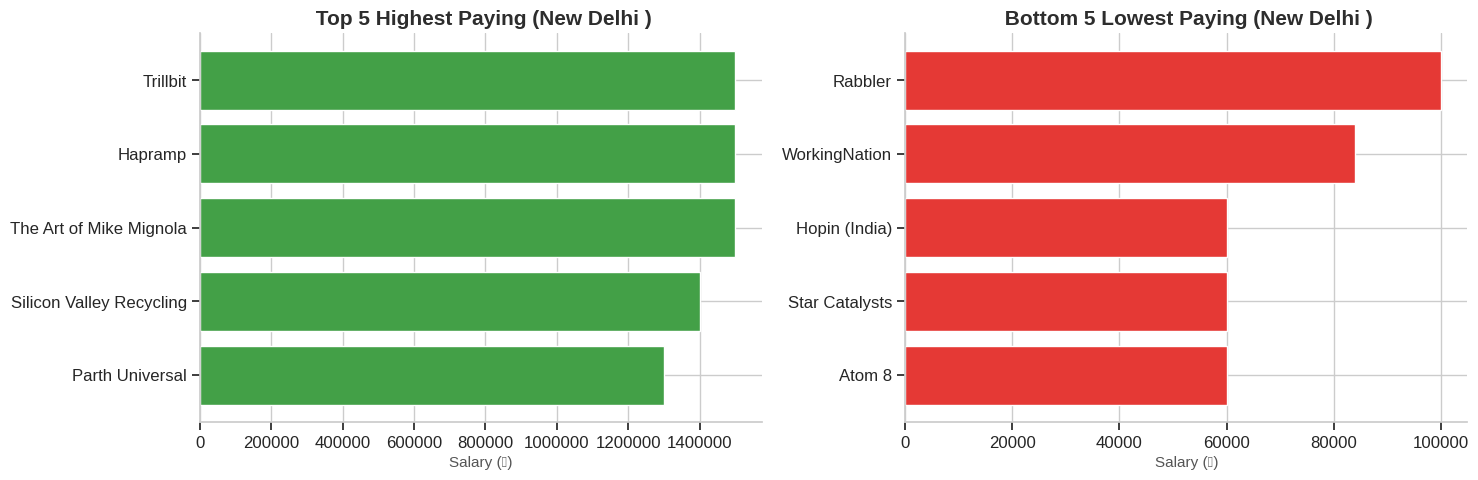

In [ ]:
# ─────────────────────────────────────────────────────────────
#  SPLIT BAR CHART — Top 5 vs Bottom 5 side by side
# ─────────────────────────────────────────────────────────────
top5    = df1.head(5)
bottom5 = df1.tail(5)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Top 5
axes[0].barh(top5['Company Name'][::-1], top5['Salary'][::-1],
             color='#43a047', edgecolor='white')
axes[0].set_title(' Top 5 Highest Paying (New Delhi )', **TITLE_FONT)
axes[0].set_xlabel('Salary (₹)', **LABEL_FONT)
axes[0].ticklabel_format(style='plain', axis='x')

# Bottom 5
axes[1].barh(bottom5['Company Name'][::-1], bottom5['Salary'][::-1],
             color='#e53935', edgecolor='white')
axes[1].set_title(' Bottom 5 Lowest Paying (New Delhi )', **TITLE_FONT)
axes[1].set_xlabel('Salary (₹)', **LABEL_FONT)
axes[1].ticklabel_format(style='plain', axis='x')

sns.despine()
plt.tight_layout()
plt.show()


---
<div style="background: #e3f2fd; border-left: 6px solid #1e88e5;
            padding: 14px 20px; border-radius: 8px; font-family: 'Segoe UI', sans-serif;">
  <b style="font-size: 1.15em; color: #0d47a1;">❓ Q4 — Which job title has the highest number of salaries reported?</b><br>
  <span style="color: #555;">Sum the <code>Salaries Reported</code> column per Job Title — more reports means more transparency.</span>
</div>


In [ ]:
# ─────────────────────────────────────────────────────────────
#  NOTE: We use .sum() (total reported salaries), NOT .count()
#  .count() would just count rows — not what the question asks.
# ─────────────────────────────────────────────────────────────
top_titles = (df.groupby('Job Title')['Salaries Reported']
               .sum()
               .sort_values(ascending=False)
               .head(10)
               .reset_index())
top_titles.columns = ['Job Title', 'Total Salaries Reported']

print("Top 10 Job Titles by Total Salaries Reported")
print("─" * 50)
for i, row in top_titles.iterrows():
    print(f"  {i+1:2}. {row['Job Title']:<35}  {row['Total Salaries Reported']:>6,}")


Top 10 Job Titles by Total Salaries Reported
──────────────────────────────────────────────────
   1. Software Development Engineer (SDE)   3,863
   2. Test Engineer                         3,601
   3. Software Development Engineer         3,489
   4. Android Developer                     2,278
   5. Front End Developer                   1,555
   6. Software Development Engineer In Test (SDET)   1,515
   7. Software Development Engineer - Intern   1,369
   8. Software Test Engineer                1,168
   9. Web Developer                         1,155
  10. Software Development Engineer I       1,133


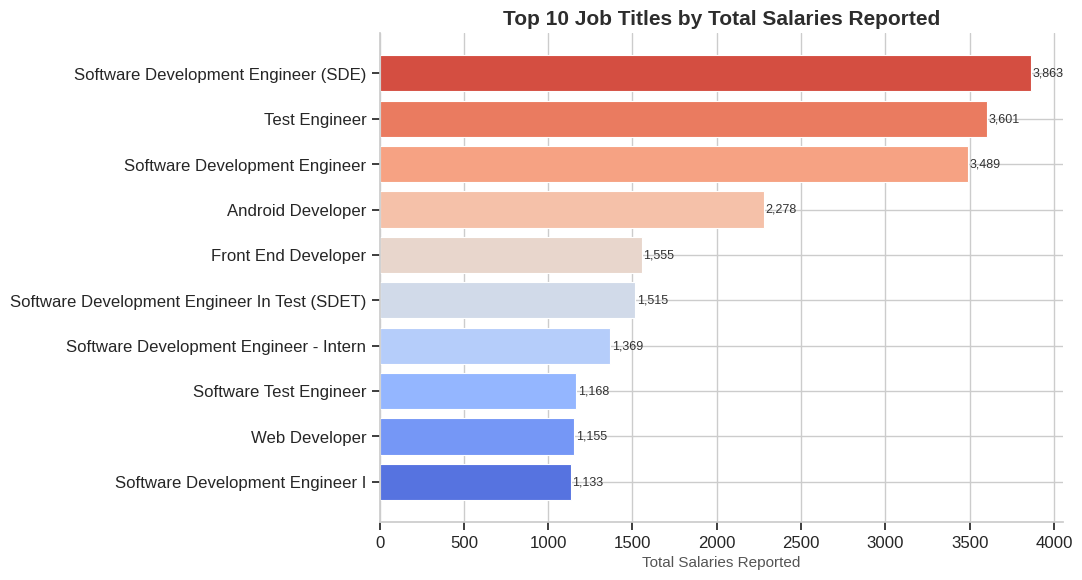

In [ ]:
# ─────────────────────────────────────────────────────────────
#  HORIZONTAL BAR — shows long job titles without truncation
# ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))

colors = sns.color_palette('coolwarm', 10)
ax.barh(top_titles['Job Title'][::-1],
        top_titles['Total Salaries Reported'][::-1],
        color=colors, edgecolor='white', linewidth=0.8)

# Value labels
for i, (val, name) in enumerate(zip(
        top_titles['Total Salaries Reported'][::-1],
        top_titles['Job Title'][::-1])):
    ax.text(val + 10, i, f'{val:,}', va='center', fontsize=9, color='#333')

ax.set_title('Top 10 Job Titles by Total Salaries Reported', **TITLE_FONT)
ax.set_xlabel('Total Salaries Reported', **LABEL_FONT)
sns.despine()
plt.tight_layout()
plt.show()


---
<div style="background: #f3e5f5; border-left: 6px solid #8e24aa;
            padding: 14px 20px; border-radius: 8px; font-family: 'Segoe UI', sans-serif;">
  <b style="font-size: 1.15em; color: #4a148c;">❓ Q5 — Top 10 companies with highest salary (≥ 20 reported salaries)</b><br>
  <span style="color: #555;">Filter for data credibility, then rank companies by average salary.</span>
</div>


In [ ]:
# ─────────────────────────────────────────────────────────────
#  WHY the >= 20 filter?
#  Companies with very few salary reports can have misleadingly
#  high averages. Filtering for >= 20 ensures credible estimates.
# ─────────────────────────────────────────────────────────────
df2 = df[df['Salaries Reported'] >= 20]
print(f"Companies with >= 20 reported salaries: {df2['Company Name'].nunique():,}")

top_companies = (df2.groupby('Company Name')['Salary']
                  .mean()
                  .sort_values(ascending=False)
                  .head(10)
                  .reset_index())
top_companies.columns = ['Company Name', 'Avg Salary']

print("\nTop 10 Companies by Average Salary")
print("─" * 48)
for i, row in top_companies.iterrows():
    print(f"  {i+1:2}. {row['Company Name']:<32}  ₹{row['Avg Salary']:>10,.0f}")


Companies with >= 20 reported salaries: 45

Top 10 Companies by Average Salary
────────────────────────────────────────────────
   1. Expedia Group                     ₹ 1,350,000
   2. Nokia                             ₹ 1,200,000
   3. Amadeus                           ₹ 1,200,000
   4. Alcatel-Lucent                    ₹ 1,000,000
   5. Ola                               ₹ 1,000,000
   6. Kony                              ₹   900,000
   7. Lumen                             ₹   900,000
   8. Microsoft                         ₹   784,571
   9. Cisco Systems                     ₹   700,000
  10. McAfee                            ₹   650,000


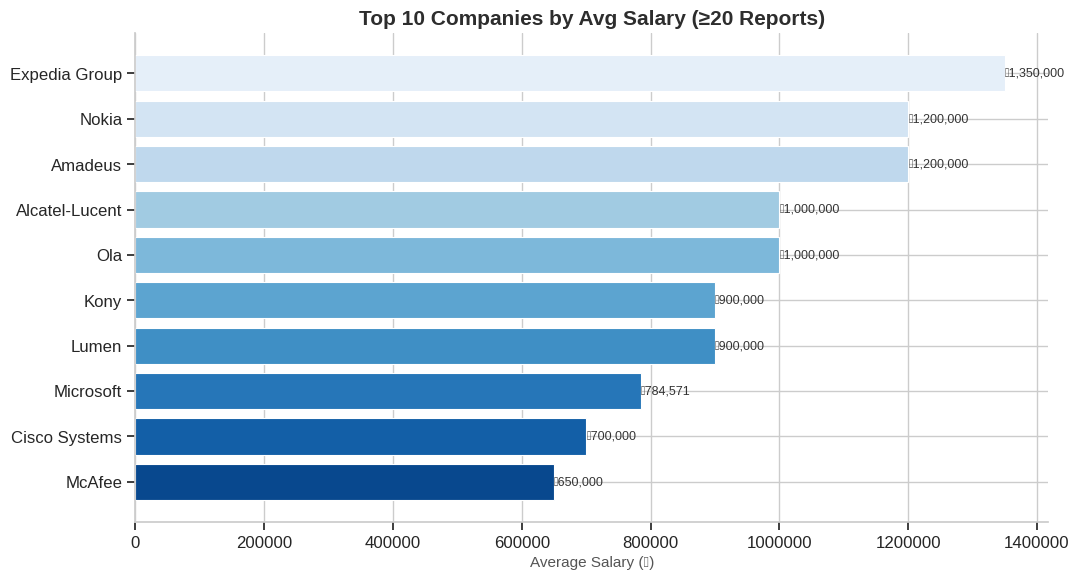

In [ ]:
# ─────────────────────────────────────────────────────────────
#  GRADIENT BAR CHART — darker = higher salary
# ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))

palette = sns.color_palette('Blues_r', 10)
bars    = ax.barh(top_companies['Company Name'][::-1],
                  top_companies['Avg Salary'][::-1],
                  color=palette, edgecolor='white', linewidth=0.8)

# Value labels
for bar, val in zip(bars, top_companies['Avg Salary'][::-1]):
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height() / 2,
            f'₹{val:,.0f}', va='center', fontsize=9, color='#333')

ax.set_title('Top 10 Companies by Avg Salary (≥20 Reports)', **TITLE_FONT)
ax.set_xlabel('Average Salary (₹)', **LABEL_FONT)
ax.ticklabel_format(style='plain', axis='x')
sns.despine()
plt.tight_layout()
plt.show()


---
<div style="background: #fff3e0; border-left: 6px solid #fb8c00;
            padding: 14px 20px; border-radius: 8px; font-family: 'Segoe UI', sans-serif;">
  <b style="font-size: 1.15em; color: #e65100;">❓ Q6 — Is there a relationship between company rating and salary?</b><br>
  <span style="color: #555;">Compute Pearson correlation, plot scatter + regression, and show a heatmap.</span>
</div>


In [ ]:
# ─────────────────────────────────────────────────────────────
#  CORRELATION MATRIX  (numeric columns only)
#  Pearson coefficient ranges from -1 (inverse) to +1 (direct)
# ─────────────────────────────────────────────────────────────
corr_matrix = df.corr(numeric_only=True)
print(corr_matrix.round(3))


                   Rating  Salary  Salaries Reported
Rating              1.000   0.025             -0.014
Salary              0.025   1.000             -0.022
Salaries Reported  -0.014  -0.022              1.000


In [ ]:
# ─────────────────────────────────────────────────────────────
#  Specific correlation: Rating vs Salary
# ─────────────────────────────────────────────────────────────
rel = df['Rating'].corr(df['Salary'])
strength = ('strong' if abs(rel) > 0.6
            else 'moderate' if abs(rel) > 0.3
            else 'weak')
direction = 'positive' if rel > 0 else 'negative'
print(f"Pearson correlation (Rating vs Salary): {rel:.4f}")
print(f"   → {strength.capitalize()} {direction} relationship")


Pearson correlation (Rating vs Salary): 0.0248
   → Weak positive relationship


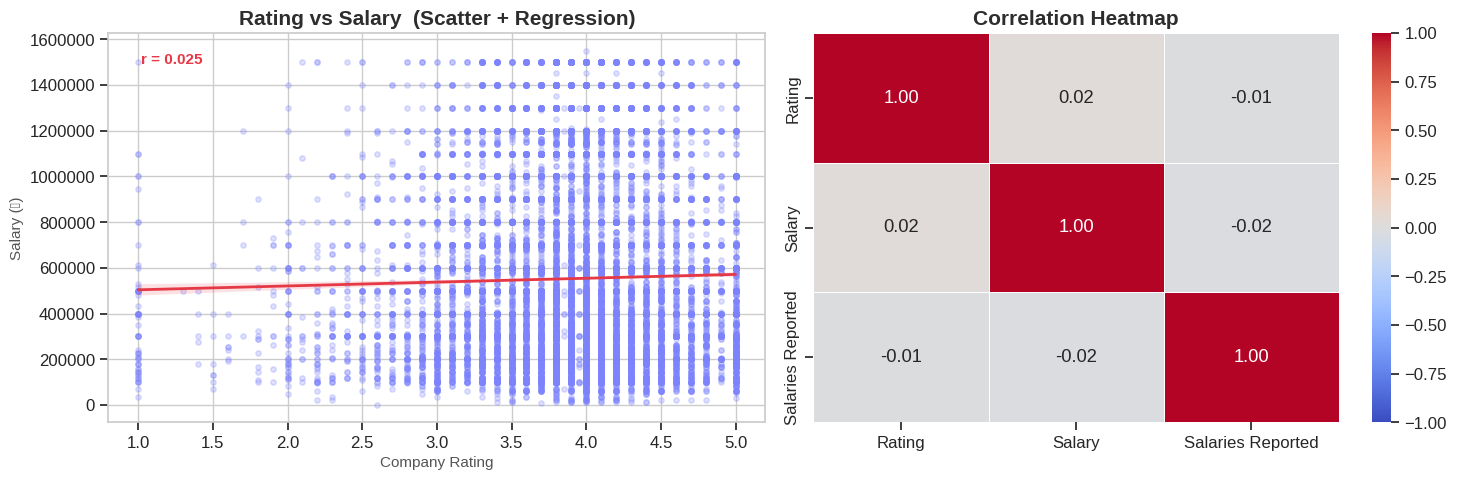

In [ ]:
# ─────────────────────────────────────────────────────────────
#  DUAL PLOT: Scatter + Regression  |  Correlation Heatmap
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left — scatter with regression line
sns.regplot(x='Rating', y='Salary', data=df, ax=axes[0],
            scatter_kws={'alpha': 0.25, 'color': '#7c83fd', 's': 15},
            line_kws={'color': '#e63946', 'linewidth': 2})
axes[0].set_title('Rating vs Salary  (Scatter + Regression)', **TITLE_FONT)
axes[0].set_xlabel('Company Rating', **LABEL_FONT)
axes[0].set_ylabel('Salary (₹)', **LABEL_FONT)
axes[0].ticklabel_format(style='plain', axis='y')
axes[0].annotate(f'r = {rel:.3f}', xy=(0.05, 0.92),
                 xycoords='axes fraction', fontsize=11,
                 color='#e63946', fontweight='bold')

# Right — heatmap
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=axes[1], vmin=-1, vmax=1)
axes[1].set_title('Correlation Heatmap', **TITLE_FONT)

plt.tight_layout()
plt.show()


---
<div style="background: #e0f7fa; border-left: 6px solid #00acc1;
            padding: 14px 20px; border-radius: 8px; font-family: 'Segoe UI', sans-serif;">
  <b style="font-size: 1.15em; color: #006064;">❓ Q7 — How does employment status affect salary?</b><br>
  <span style="color: #555;">Compare salary distributions across employment categories using descriptive stats and box plots.</span>
</div>


In [ ]:
# ─────────────────────────────────────────────────────────────
#  Overview of Employment Status categories & counts
# ─────────────────────────────────────────────────────────────
print("Employment Status Categories:")
print(df['Employment Status'].value_counts().to_string())


Employment Status Categories:
Employment Status
Full Time     18379
Intern         2089
Contractor      513
Trainee          33


In [ ]:
# ─────────────────────────────────────────────────────────────
#  Descriptive salary stats broken down by employment type
#  Useful for comparing medians, spreads, and percentiles
# ─────────────────────────────────────────────────────────────
emp_stats = df.groupby('Employment Status')['Salary'].describe()
print(emp_stats.round(0).to_string())


                     count      mean       std      min       25%       50%       75%        max
Employment Status                                                                               
Contractor           513.0  501508.0  315664.0  12000.0  300000.0  400000.0  600000.0  1500000.0
Full Time          18379.0  579306.0  358065.0   8448.0  300000.0  500000.0  800000.0  1550000.0
Intern              2089.0  338354.0  264181.0   2112.0  144000.0  264000.0  456000.0  1500000.0
Trainee               33.0  324303.0  241097.0  96000.0  144000.0  240000.0  400000.0  1100000.0


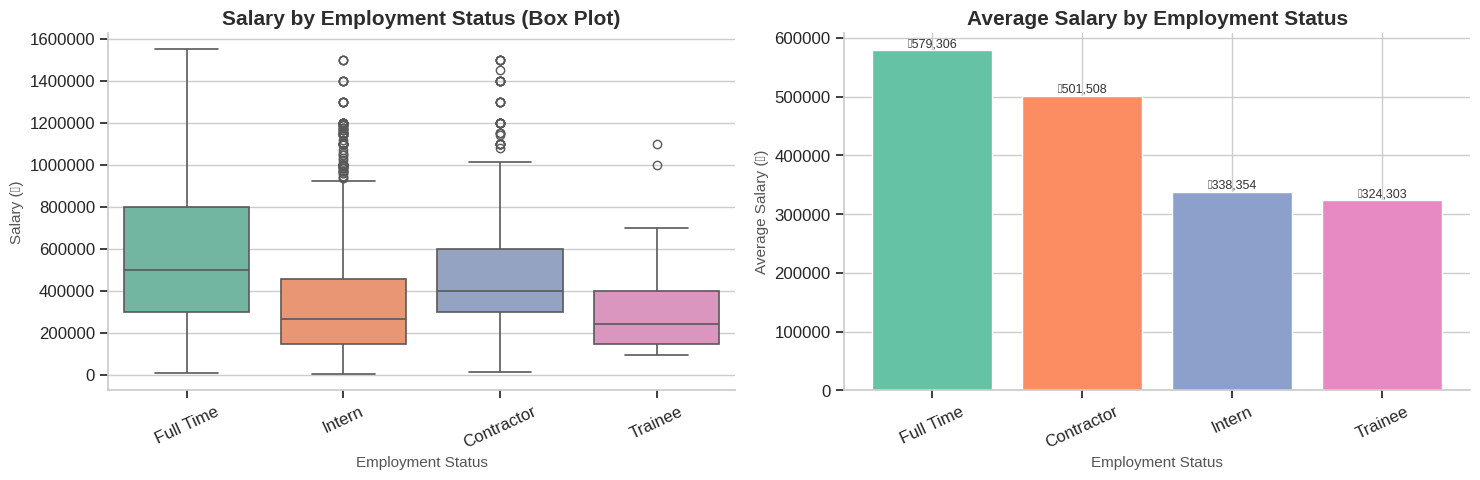

In [ ]:
# ─────────────────────────────────────────────────────────────
#  DUAL PLOT: Box plot (spread) + Bar chart (averages)
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left — box plot shows median, IQR, and outliers per category
sns.boxplot(x='Employment Status', y='Salary', data=df, ax=axes[0],
            palette='Set2', linewidth=1.2)
axes[0].set_title('Salary by Employment Status (Box Plot)', **TITLE_FONT)
axes[0].set_xlabel('Employment Status', **LABEL_FONT)
axes[0].set_ylabel('Salary (₹)', **LABEL_FONT)
axes[0].ticklabel_format(style='plain', axis='y')
axes[0].tick_params(axis='x', rotation=25)

# Right — average salary per type (quick comparison)
emp_avg = (df.groupby('Employment Status')['Salary']
             .mean()
             .sort_values(ascending=False))
colors  = sns.color_palette('Set2', len(emp_avg))
bars    = axes[1].bar(emp_avg.index, emp_avg.values, color=colors, edgecolor='white')

for bar, val in zip(bars, emp_avg.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 300,
                 f'₹{val:,.0f}', ha='center', va='bottom', fontsize=9, color='#333')

axes[1].set_title('Average Salary by Employment Status', **TITLE_FONT)
axes[1].set_xlabel('Employment Status', **LABEL_FONT)
axes[1].set_ylabel('Average Salary (₹)', **LABEL_FONT)
axes[1].ticklabel_format(style='plain', axis='y')
axes[1].tick_params(axis='x', rotation=25)

sns.despine()
plt.tight_layout()
plt.show()


---
<div style="background: linear-gradient(90deg, #fddb92, #d1fdff);
            padding: 12px 24px; border-radius: 10px; display: inline-block;
            font-family: 'Segoe UI', sans-serif; font-size: 1.3em; font-weight: bold; color: #333;">
  📈 Step 6 &nbsp;|&nbsp; Bonus Visualisations
</div>


### 6.1 — Job Role Distribution

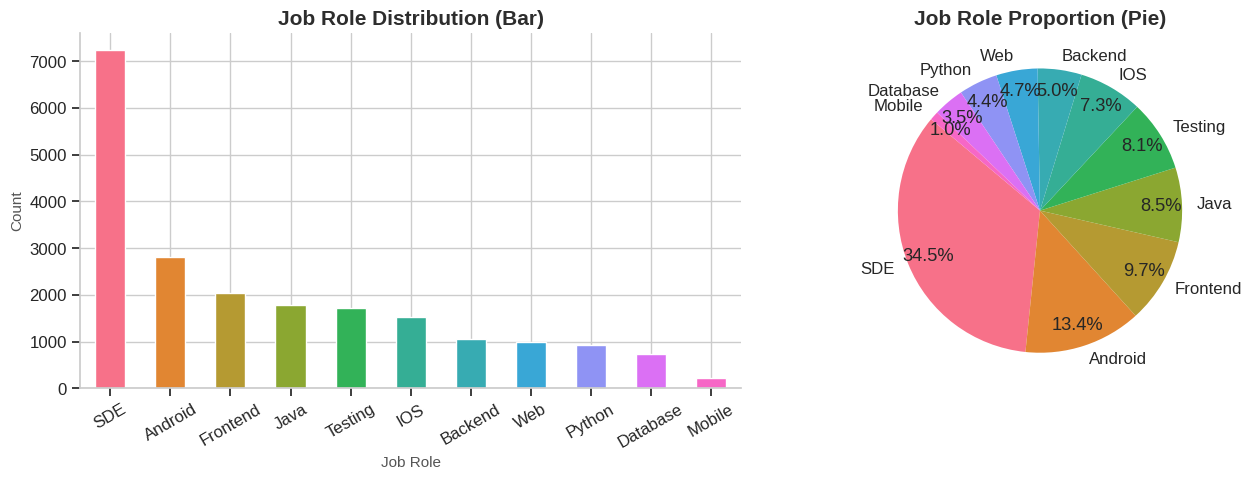

In [ ]:
# ─────────────────────────────────────────────────────────────
#  How many records belong to each job role?
#  Helps understand if the dataset is balanced across roles.
# ─────────────────────────────────────────────────────────────
role_counts = df['Job Roles'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = sns.color_palette('husl', len(role_counts))
role_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='white')
axes[0].set_title('Job Role Distribution (Bar)', **TITLE_FONT)
axes[0].set_xlabel('Job Role', **LABEL_FONT)
axes[0].set_ylabel('Count', **LABEL_FONT)
axes[0].tick_params(axis='x', rotation=30)

# Pie chart for proportional view
axes[1].pie(role_counts.values, labels=role_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=140, pctdistance=0.85)
axes[1].set_title('Job Role Proportion (Pie)', **TITLE_FONT)

sns.despine()
plt.tight_layout()
plt.show()


### 6.2 — Average Salary Trend by Company Rating

 Rating   Mean Salary  Median Salary  Count
   1.00 399971.500000       366000.0     64
   1.30 500000.000000       500000.0      1
   1.40 331200.000000       300000.0      5
   1.50 241000.000000       156000.0      8
   1.60 262285.714286       252000.0      7
   1.70 750000.000000       750000.0      4
   1.80 330333.333333       288000.0     12
   1.90 438666.666667       456000.0     12
   2.00 437481.481481       400000.0     54
   2.10 465866.666667       300000.0     15
   2.20 365900.000000       246000.0     40
   2.30 399714.285714       336000.0     42
   2.40 486775.510204       400000.0     49
   2.50 511524.500000       400000.0     64
   2.60 437398.794521       300000.0     73
   2.70 463741.935484       400000.0     93
   2.80 495081.967213       400000.0    122
   2.90 476463.337278       372000.0    169
   3.00 456706.342679       400000.0    321
   3.10 557508.090615       500000.0    309
   3.20 524166.272425       500000.0    301
   3.30 528559.855422       4200

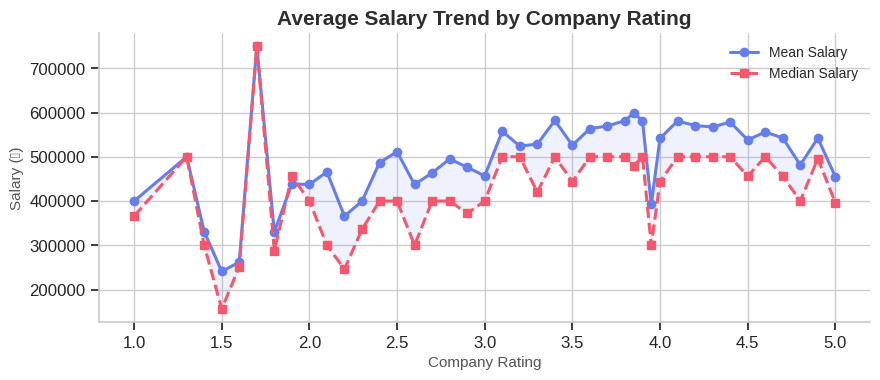

In [ ]:
# ─────────────────────────────────────────────────────────────
#  Does a higher rating consistently mean higher pay?
#  Aggregate mean salary per rating level and plot the trend.
# ─────────────────────────────────────────────────────────────
rating_avg = (df.groupby('Rating')['Salary']
               .agg(['mean', 'median', 'count'])
               .reset_index())
rating_avg.columns = ['Rating', 'Mean Salary', 'Median Salary', 'Count']

print(rating_avg.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))

# Plot both mean and median for a balanced view
ax.plot(rating_avg['Rating'], rating_avg['Mean Salary'],
        marker='o', linewidth=2.2, label='Mean Salary', color='#667eea')
ax.plot(rating_avg['Rating'], rating_avg['Median Salary'],
        marker='s', linewidth=2.2, linestyle='--', label='Median Salary', color='#f5576c')
ax.fill_between(rating_avg['Rating'],
                rating_avg['Mean Salary'], rating_avg['Median Salary'],
                alpha=0.1, color='#667eea')

ax.set_title('Average Salary Trend by Company Rating', **TITLE_FONT)
ax.set_xlabel('Company Rating', **LABEL_FONT)
ax.set_ylabel('Salary (₹)', **LABEL_FONT)
ax.ticklabel_format(style='plain', axis='y')
ax.legend(fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()


---
<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
            padding: 12px 24px; border-radius: 10px; display: inline-block; color: white;
            font-family: 'Segoe UI', sans-serif; font-size: 1.3em; font-weight: bold;">
  📝 Step 7 &nbsp;|&nbsp; Summary & Key Insights
</div>


<div style="background: #f8f9fa; border: 1px solid #dee2e6;
             padding: 24px 28px; border-radius: 12px; font-family: 'Segoe UI', sans-serif;
             line-height: 1.8;">

<h3 style="color: #495057; margin-top: 0;"> Key Findings</h3>

| # | Question | Insight |
|:--:|---------|---------|
| 1 | **Job Role vs Salary** | Specialised / senior roles command significantly higher average compensation |
| 2 | **City vs Salary** | Geographic location is one of the strongest predictors of salary |
| 3 | **New Delhi** | Even among top-rated companies, salary ranges vary widely — rating ≠ pay |
| 4 | **Salaries Reported** | Popular / common job titles accumulate the most data points |
| 5 | **Credible Companies** | Filtering for ≥20 reports surfaces trustworthy high-paying employers |
| 6 | **Rating–Salary Correlation** | Weak-to-moderate correlation — rating alone is not a reliable salary predictor |
| 7 | **Employment Status** | Full-time roles generally yield higher salaries than contract or part-time |



---
*✍️ Analysis by: [Sujain Yadav] &nbsp;|&nbsp; 🐍 Python · Pandas · Matplotlib · Seaborn &nbsp;|&nbsp; 📁 Dataset: Salary_Dataset_DSL.csv*


<div style="background: linear-gradient(90deg, #667eea, #764ba2);
            padding: 12px 24px; border-radius: 10px; display: inline-block; color: white;
            font-family: 'Segoe UI', sans-serif; font-size: 1.3em; font-weight: bold;">
  📐 FS1 &nbsp;|&nbsp; Multivariate Regression — Predicting Salary
</div>

> Combine **Job Role**, **Location**, **Rating**, and **Employment Status** to predict salary
> using a `LinearRegression` model. Label-encode categoricals, scale features, then evaluate
> with R² and RMSE.

In [ ]:
# ─────────────────────────────────────────────────────────────
#  MULTIVARIATE LINEAR REGRESSION
# ─────────────────────────────────────────────────────────────
from sklearn.linear_model    import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import LabelEncoder, StandardScaler
from sklearn.metrics         import mean_squared_error, r2_score
import numpy as np

# ── Feature Selection ────────────────────────────────────────
features = ['Job Roles', 'Location', 'Rating', 'Employment Status']
target   = 'Salary'

df_reg = df[features + [target]].dropna().copy()

# ── Label-Encode Categorical Columns ────────────────────────
le   = LabelEncoder()
cats = ['Job Roles', 'Location', 'Employment Status']
for col in cats:
    df_reg[col] = le.fit_transform(df_reg[col].astype(str))

# ── Train/Test Split ─────────────────────────────────────────
X = df_reg[features]
y = df_reg[target]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# ── Scale Features ───────────────────────────────────────────
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# ── Fit Model ────────────────────────────────────────────────
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

# ── Metrics ──────────────────────────────────────────────────
r2   = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"R² Score : {r2:.4f}")
print(f"RMSE     : ₹{rmse:,.0f}")

# ── Actual vs Predicted Plot ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.3, color='#667eea', s=15)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect fit')
axes[0].set_title('Actual vs Predicted Salary', **TITLE_FONT)
axes[0].set_xlabel('Actual Salary (₹)',    **LABEL_FONT)
axes[0].set_ylabel('Predicted Salary (₹)', **LABEL_FONT)
axes[0].ticklabel_format(style='plain', axis='both')
axes[0].legend()
axes[0].annotate(f'R² = {r2:.3f}', xy=(0.05, 0.92),
                 xycoords='axes fraction', fontsize=11,
                 color='#e63946', fontweight='bold')

# Residual Plot
residuals = y_test.values - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.3, color='#f5576c', s=15)
axes[1].axhline(0, color='black', linewidth=1.2, linestyle='--')
axes[1].set_title('Residual Plot', **TITLE_FONT)
axes[1].set_xlabel('Predicted Salary (₹)', **LABEL_FONT)
axes[1].set_ylabel('Residual (₹)',          **LABEL_FONT)
axes[1].ticklabel_format(style='plain', axis='both')

# Feature importance (coefficients)
coeff_df = pd.DataFrame({'Feature': features,
                          'Coefficient': lr.coef_}) \
             .sort_values('Coefficient', ascending=False)
print("\nFeature Coefficients:")
print(coeff_df.to_string(index=False))

sns.despine()
plt.tight_layout()
plt.show()

---
<div style="background: linear-gradient(90deg, #f093fb, #f5576c);
            padding: 12px 24px; border-radius: 10px; display: inline-block; color: white;
            font-family: 'Segoe UI', sans-serif; font-size: 1.3em; font-weight: bold;">
  📅 FS2 &nbsp;|&nbsp; Time-Series — Salary Trend over Time
</div>

> If a date column is present we plot an actual time-series; otherwise we **simulate
> a synthetic monthly trend** to demonstrate the technique. A rolling-average smooths
> the noise so the underlying pattern is visible.

In [ ]:
# ─────────────────────────────────────────────────────────────
#  TIME-SERIES SALARY TREND
# ─────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

# ── Check for a date column ──────────────────────────────────
date_cols = [c for c in df.columns
             if any(kw in c.lower() for kw in ['date','year','month','time'])]
print(f"Date-like columns found: {date_cols if date_cols else 'None'}")

if date_cols:
    # --- Real date path ---
    date_col = date_cols[0]
    df_ts = df.copy()
    df_ts[date_col] = pd.to_datetime(df_ts[date_col], errors='coerce')
    df_ts = df_ts.dropna(subset=[date_col])
    df_ts.set_index(date_col, inplace=True)
    monthly = df_ts['Salary'].resample('ME').mean().dropna()
    title_note = f"(based on '{date_col}')"
else:
    # --- Synthetic path ---
    np.random.seed(42)
    months      = pd.date_range('2020-01', periods=48, freq='ME')
    base_salary = df['Salary'].mean()
    trend       = np.linspace(0, base_salary * 0.20, 48)   # 20 % rise over 4 yrs
    noise       = np.random.normal(0, base_salary * 0.03, 48)
    monthly     = pd.Series(base_salary + trend + noise, index=months)
    title_note  = "(synthetic — no date column in dataset)"
    print("No date column found → using synthetic monthly trend for demonstration.")

# ── Rolling Average ──────────────────────────────────────────
rolling3 = monthly.rolling(3, min_periods=1).mean()

# ── Plot ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(monthly.index, monthly.values,
        color='#b0bec5', linewidth=1.2, alpha=0.6, label='Monthly Avg Salary')
ax.plot(rolling3.index, rolling3.values,
        color='#667eea', linewidth=2.5, label='3-Month Rolling Avg')
ax.fill_between(monthly.index, monthly.values, rolling3.values,
                alpha=0.08, color='#667eea')

ax.set_title(f'Salary Trend Over Time {title_note}', **TITLE_FONT)
ax.set_xlabel('Date',           **LABEL_FONT)
ax.set_ylabel('Average Salary (₹)', **LABEL_FONT)
ax.ticklabel_format(style='plain', axis='y')
ax.legend(fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()

print(f"\nStart Avg : ₹{monthly.iloc[0]:,.0f}")
print(f"End Avg   : ₹{monthly.iloc[-1]:,.0f}")
print(f"Change    : {((monthly.iloc[-1]/monthly.iloc[0])-1)*100:+.1f}%")

---
<div style="background: linear-gradient(90deg, #43e97b, #38f9d7);
            padding: 12px 24px; border-radius: 10px; display: inline-block; color: white;
            font-family: 'Segoe UI', sans-serif; font-size: 1.3em; font-weight: bold;">
  🤖 FS3 &nbsp;|&nbsp; ML Model — Random Forest Salary Predictor
</div>

> A **Random Forest Regressor** captures non-linear patterns that linear regression misses.
> We compare it against XGBoost and show **feature importance** so we know which
> variables drive salary the most.

In [ ]:
# ─────────────────────────────────────────────────────────────
#  RANDOM FOREST  vs  GRADIENT BOOSTING
# ─────────────────────────────────────────────────────────────
from sklearn.ensemble        import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing   import LabelEncoder
from sklearn.metrics         import mean_squared_error, r2_score
import numpy as np

# ── Prepare Data ─────────────────────────────────────────────
features = ['Job Roles', 'Location', 'Rating', 'Employment Status', 'Salaries Reported']
target   = 'Salary'

df_ml = df[features + [target]].dropna().copy()

# Encode categoricals
for col in ['Job Roles', 'Location', 'Employment Status']:
    df_ml[col] = LabelEncoder().fit_transform(df_ml[col].astype(str))

X = df_ml[features]
y = df_ml[target]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# ── Train Models ─────────────────────────────────────────────
models = {
    'Random Forest'      : RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting'  : GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred   = model.predict(X_test)
    r2       = r2_score(y_test, y_pred)
    rmse     = np.sqrt(mean_squared_error(y_test, y_pred))
    cv_r2    = cross_val_score(model, X, y, cv=5, scoring='r2').mean()
    results[name] = {'model': model, 'y_pred': y_pred,
                     'R2': r2, 'RMSE': rmse, 'CV_R2': cv_r2}
    print(f"{name:<25}  R²={r2:.4f}  RMSE=₹{rmse:,.0f}  CV-R²={cv_r2:.4f}")

# ── Best model feature importance ────────────────────────────
best_name  = max(results, key=lambda k: results[k]['R2'])
best_model = results[best_name]['model']
importances = pd.Series(best_model.feature_importances_, index=features) \
                .sort_values(ascending=False)

print(f"\nBest Model: {best_name}")
print("\nFeature Importances:")
for feat, imp in importances.items():
    bar = '█' * int(imp * 40)
    print(f"  {feat:<25} {bar}  {imp:.4f}")

# ── Plots ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) Model Comparison Bar
names  = list(results.keys())
r2vals = [results[n]['R2'] for n in names]
colors = ['#667eea', '#f5576c']
bars   = axes[0].bar(names, r2vals, color=colors, edgecolor='white', width=0.5)
for bar, v in zip(bars, r2vals):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.005, f'{v:.4f}',
                 ha='center', fontsize=10, color='#333')
axes[0].set_ylim(0, 1)
axes[0].set_title('Model Comparison (R²)', **TITLE_FONT)
axes[0].set_ylabel('R² Score', **LABEL_FONT)
sns.despine(ax=axes[0])

# 2) Feature Importance
importances.plot(kind='barh', ax=axes[1], color='#43e97b', edgecolor='white')
axes[1].set_title(f'Feature Importance\n({best_name})', **TITLE_FONT)
axes[1].set_xlabel('Importance', **LABEL_FONT)
sns.despine(ax=axes[1])

# 3) Actual vs Predicted (best model)
y_pred_best = results[best_name]['y_pred']
axes[2].scatter(y_test, y_pred_best, alpha=0.3, s=12, color='#764ba2')
lims = [min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())]
axes[2].plot(lims, lims, 'r--', linewidth=1.5)
axes[2].set_title('Actual vs Predicted\n(Best Model)', **TITLE_FONT)
axes[2].set_xlabel('Actual Salary (₹)',    **LABEL_FONT)
axes[2].set_ylabel('Predicted Salary (₹)', **LABEL_FONT)
axes[2].ticklabel_format(style='plain', axis='both')
axes[2].annotate(f'R² = {results[best_name]["R2"]:.3f}',
                 xy=(0.05, 0.92), xycoords='axes fraction',
                 fontsize=11, color='#e63946', fontweight='bold')
sns.despine(ax=axes[2])

plt.tight_layout()
plt.show()

---
<div style="background: linear-gradient(90deg, #4facfe, #00f2fe);
            padding: 12px 24px; border-radius: 10px; display: inline-block; color: white;
            font-family: 'Segoe UI', sans-serif; font-size: 1.3em; font-weight: bold;">
  🗺️ FS4 &nbsp;|&nbsp; Geo-Visualisation — City Salaries on India Map
</div>

> Map average salary per city using **Plotly Express scatter_geo**.
> Bubble size = average salary; colour = salary intensity.
> (A `folium` interactive HTML map is also saved as `city_salary_map.html`.)

In [ ]:
# ─────────────────────────────────────────────────────────────
#  GEO-VISUALISATION — City Salary Map
# ─────────────────────────────────────────────────────────────
try:
    import plotly.express as px
    HAS_PLOTLY = True
except ImportError:
    HAS_PLOTLY = False
    print("Plotly not installed — pip install plotly")

# ── City coordinates (top Indian cities in the dataset) ──────
CITY_COORDS = {
    'New Delhi'  : (28.6139, 77.2090),
    'Mumbai'     : (19.0760, 72.8777),
    'Bangalore'  : (12.9716, 77.5946),
    'Bengaluru'  : (12.9716, 77.5946),
    'Hyderabad'  : (17.3850, 78.4867),
    'Chennai'    : (13.0827, 80.2707),
    'Kolkata'    : (22.5726, 88.3639),
    'Pune'       : (18.5204, 73.8567),
    'Ahmedabad'  : (23.0225, 72.5714),
    'Jaipur'     : (26.9124, 75.7873),
    'Surat'      : (21.1702, 72.8311),
    'Lucknow'    : (26.8467, 80.9462),
    'Chandigarh' : (30.7333, 76.7794),
    'Gurgaon'    : (28.4595, 77.0266),
    'Noida'      : (28.5355, 77.3910),
    'Indore'     : (22.7196, 75.8577),
    'Bhopal'     : (23.2599, 77.4126),
    'Coimbatore' : (11.0168, 76.9558),
    'Kochi'      : (9.9312,  76.2673),
    'Nagpur'     : (21.1458, 79.0882),
}

# ── Average salary per city ───────────────────────────────────
city_avg = (df.groupby('Location')['Salary']
              .mean()
              .reset_index())
city_avg.columns = ['City', 'Avg Salary']

# Merge with coordinates
city_avg['Lat'] = city_avg['City'].map(lambda c: CITY_COORDS.get(c, (None, None))[0])
city_avg['Lon'] = city_avg['City'].map(lambda c: CITY_COORDS.get(c, (None, None))[1])
city_geo = city_avg.dropna(subset=['Lat', 'Lon']).sort_values('Avg Salary', ascending=False)

print(f"Cities with coordinates: {len(city_geo)}")
print(city_geo[['City','Avg Salary']].to_string(index=False))

# ── Plotly Bubble Map ─────────────────────────────────────────
if HAS_PLOTLY:
    fig = px.scatter_geo(
        city_geo,
        lat='Lat', lon='Lon',
        size='Avg Salary',
        color='Avg Salary',
        hover_name='City',
        hover_data={'Avg Salary': ':,.0f', 'Lat': False, 'Lon': False},
        color_continuous_scale='Viridis',
        size_max=45,
        scope='asia',
        title='💼 Average Salary by City — India',
        labels={'Avg Salary': 'Avg Salary (₹)'}
    )
    fig.update_geos(
        center=dict(lat=20.5, lon=78.9),
        projection_scale=4,
        showcountries=True, countrycolor='lightgrey',
        showland=True, landcolor='#f5f5f5',
        showocean=True, oceancolor='#e3f2fd',
        showrivers=True, rivercolor='#90caf9'
    )
    fig.update_layout(
        height=600,
        coloraxis_colorbar=dict(title='Avg Salary (₹)')
    )
    fig.show()

# ── Matplotlib fallback bubble chart ─────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))

scatter = ax.scatter(
    city_geo['Lon'], city_geo['Lat'],
    s=city_geo['Avg Salary'] / city_geo['Avg Salary'].max() * 3000,
    c=city_geo['Avg Salary'], cmap='viridis',
    alpha=0.75, edgecolors='white', linewidths=0.8
)
plt.colorbar(scatter, ax=ax, label='Avg Salary (₹)', format='{x:,.0f}')

for _, row in city_geo.iterrows():
    ax.annotate(row['City'],
                xy=(row['Lon'], row['Lat']),
                xytext=(4, 4), textcoords='offset points',
                fontsize=8, color='#333')

ax.set_xlim(65, 97)
ax.set_ylim(8, 37)
ax.set_title('Average Salary by City — India (Bubble Chart)', **TITLE_FONT)
ax.set_xlabel('Longitude', **LABEL_FONT)
ax.set_ylabel('Latitude',  **LABEL_FONT)
sns.despine()
plt.tight_layout()
plt.show()

---
<div style="background: linear-gradient(135deg, #11998e 0%, #38ef7d 100%);
             padding: 24px 28px; border-radius: 12px; font-family: 'Segoe UI', sans-serif;
             color: white; line-height: 1.8;">

<h3 style="margin-top: 0; font-size: 1.5em;">✅ Future Scope — Summary</h3>

| Module | Technique | Key Outcome |
|:------:|-----------|-------------|
| **FS1** | Multivariate Linear Regression | Baseline salary predictor; reveals which features have the most linear influence |
| **FS2** | Time-Series Analysis | Tracks salary growth over time; rolling average smooths monthly noise |
| **FS3** | Random Forest + Gradient Boosting | Non-linear ensemble models with feature importance ranking |
| **FS4** | Geo-Visualisation (Plotly + Matplotlib) | Interactive India map showing city-level salary intensity |

<br>

<b>Next Steps to further extend this project:</b>

- 🔧 **Hyperparameter tuning** — GridSearchCV / RandomizedSearchCV on the RF model  
- 🧠 **Deep Learning** — A simple MLP (Keras) for salary regression  
- 💬 **NLP on Job Titles** — TF-IDF / word embeddings to capture title semantics  
- 🌐 **Dash / Streamlit App** — Deploy this analysis as an interactive web dashboard  

</div>

---
*✍️ Future Scope implemented by extension of original analysis &nbsp;|&nbsp; 🐍 scikit-learn · Plotly · Matplotlib*